## **JURNAL MODUL 4**

In [129]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import pandas as pd

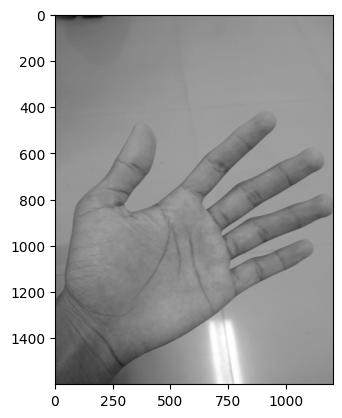

In [130]:
img_tangan = plt.imread('telapaktangan.jpeg')
img_tangan_gray = cv.cvtColor(img_tangan, cv.COLOR_RGB2GRAY)
plt.imshow(img_tangan_gray, cmap='gray')

In [131]:
def fungsi_dua(image, new_width, new_height):
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image

In [132]:
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)


sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)


robertsX = np.array([
    [1,  0],
    [0, -1]
], dtype=np.float32)

robertsY = np.array([
    [ 0, 1],
    [-1, 0]
], dtype=np.float32)

In [133]:
def sobel_manual(img):
    h, w = img.shape
    hasil = np.zeros((h, w),dtype=np.float32)

    gx = np.array([
        [-1,0,1],
        [-2,0,2],
        [-1,0,1]
    ])

    gy = np.array([
        [-1,-2,-1],
        [ 0, 0, 0],
        [ 1, 2, 1]
    ])

    for i in range(1, h-1):
        for j in range(1, w-1):
            total_x = 0
            total_y = 0
            for ki in range(-1,2):
                for kj in range(-1,2):
                    pixel = img[i+ki, j+kj]
                    total_x += (pixel * gx[ki+1, kj+1])

                    total_y += (pixel * gy[ki+1, kj+1])

            gradien = (abs(total_x) + abs(total_y))
            hasil[i,j] = gradien

    nilai_min = hasil[0,0]
    nilai_max = hasil[0,0]

    for i in range(h):
        for j in range(w):
            if hasil[i,j] < nilai_min:
                nilai_min = hasil[i,j]
            if hasil[i,j] > nilai_max:
                nilai_max = hasil[i,j]

    normal = np.zeros((h, w),
                      dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            normal[i,j] = int(
                ((hasil[i,j] - nilai_min) / (nilai_max - nilai_min)) * 255)

    for i in range(h):
        for j in range(w):
            normal[i,j] = int(normal[i,j] * 0.38)
    return normal

In [134]:
def convolution(img, kernel):
    if len(img.shape) == 3:
        height, width, channels = img.shape
    else:
        height, width = img.shape
        channels = 1
        img = img.reshape(height, width, 1)

    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, ((pad_size, pad_size), (pad_size, pad_size), (0, 0)), mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)

    for c in range(channels):
        for i in range(height):
            for j in range(width):
                region = padded[i:i+size, j:j+size, c]
                canvas[i, j, c] = np.sum(region * kernel)
    
    canvas = np.clip(canvas, 0, 255).astype(np.uint8)
    
    if channels == 1:
        return canvas.reshape(height, width)
        
    return canvas

In [135]:
def edge(img, kernelX, kernelY):

    gx = convolution(img, kernelX)
    gy = convolution(img, kernelY)

    canvas =  np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)

    return np.clip(canvas, 0, 255).astype(np.uint8)

In [136]:
def threshold_manual(img, nilai_threshold):
    h, w = img.shape
    hasil = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            if img[i,j] > nilai_threshold:
                hasil[i,j] = 255
            else:
                hasil[i,j] = 0
    return hasil

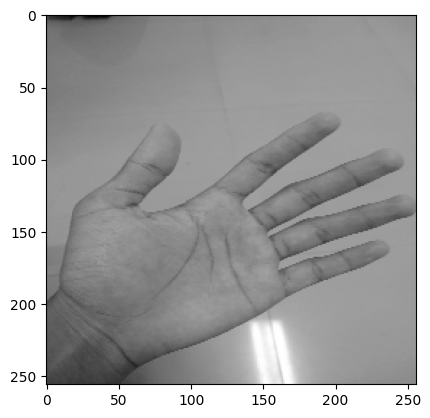

In [137]:
img_tangan_resized = fungsi_dua(img_tangan_gray, 256, 256)
plt.imshow(img_tangan_resized, cmap='gray')

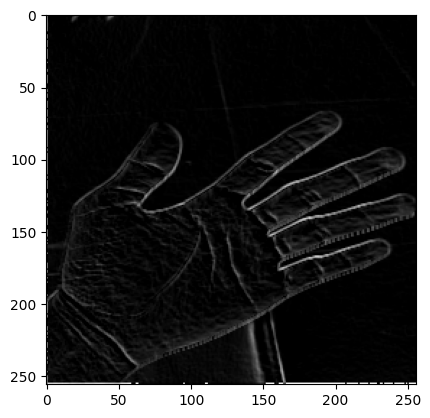

In [138]:
prewitt_tepi = edge(img_tangan_resized, prewittX, prewittY)
plt.imshow(prewitt_tepi, cmap='gray')


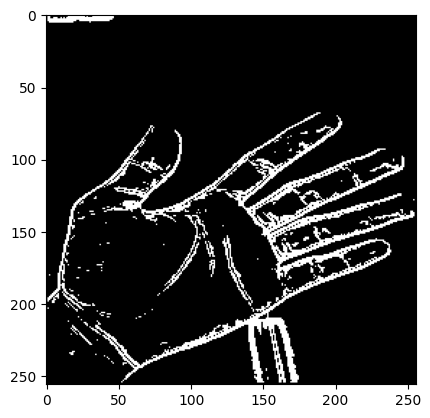

In [139]:
hasil_sobel = sobel_manual(img_tangan_resized)
threshold_10 = threshold_manual(hasil_sobel, 10)

plt.imshow(threshold_10, cmap='gray')

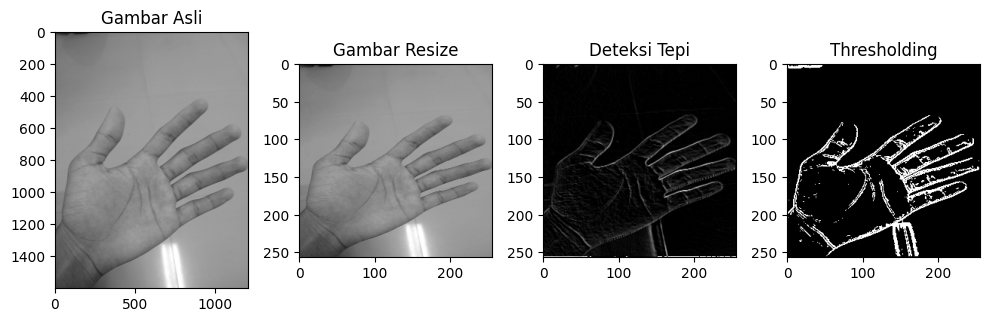

In [140]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 4, 1)
plt.imshow(img_tangan_gray, cmap='gray')
plt.title('Gambar Asli')

plt.subplot(1, 4, 2)
plt.imshow(img_tangan_resized, cmap='gray')
plt.title('Gambar Resize')

plt.subplot(1, 4, 3)
plt.imshow(prewitt_tepi, cmap='gray')
plt.title('Deteksi Tepi')

plt.subplot(1, 4, 4)
plt.imshow(threshold_10, cmap='gray')
plt.title('Thresholding')

plt.tight_layout()
plt.show()

In [141]:
def metode_satu(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i + k - center, j + l - center] = 255
            else:
                if hasil[i, j] != 255:
                    hasil[i, j] = 0
    return hasil

In [142]:
def metode_dua(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255
    return hasil

In [143]:
def metode_tiga(img):
    binary = (img > 0).astype(np.uint8)
    height, width = binary.shape
    changed = True

    while changed:
        changed = False
        hapus = []

        # STEP 1
        for i in range(1, height - 1):
            for j in range(1, width - 1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue

                P2 = binary[i - 1, j]
                P3 = binary[i - 1, j + 1]
                P4 = binary[i, j + 1]
                P5 = binary[i + 1, j + 1]
                P6 = binary[i + 1, j]
                P7 = binary[i + 1, j - 1]
                P8 = binary[i, j - 1]
                P9 = binary[i - 1, j - 1]

                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]
                jumlah = np.sum(tetangga)

                transisi = 0
                urutan = tetangga + [P2]
                for k in range(8):
                    if urutan[k] == 0 and urutan[k + 1] == 1:
                        transisi += 1

                if (
                    2 <= jumlah <= 6 and
                    transisi == 1 and
                    P2 * P4 * P6 == 0 and
                    P4 * P6 * P8 == 0
                ):
                    hapus.append((i, j))

        if hapus:
            changed = True
            for i, j in hapus:
                binary[i, j] = 0

        hapus = []

        # STEP 2
        for i in range(1, height - 1):
            for j in range(1, width - 1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue

                P2 = binary[i - 1, j]
                P3 = binary[i - 1, j + 1]
                P4 = binary[i, j + 1]
                P5 = binary[i + 1, j + 1]
                P6 = binary[i + 1, j]
                P7 = binary[i + 1, j - 1]
                P8 = binary[i, j - 1]
                P9 = binary[i - 1, j - 1]

                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]
                jumlah = np.sum(tetangga)

                transisi = 0
                urutan = tetangga + [P2]
                for k in range(8):
                    if urutan[k] == 0 and urutan[k + 1] == 1:
                        transisi += 1

                if (
                    2 <= jumlah <= 6 and
                    transisi == 1 and
                    P2 * P4 * P8 == 0 and
                    P2 * P6 * P8 == 0
                ):
                    hapus.append((i, j))

        if hapus:
            changed = True
            for i, j in hapus:
                binary[i, j] = 0

    return binary * 255

In [144]:
def metode_empat(img, kernel, iterasi=1):
    hasil = img.copy()
    for _ in range(iterasi):
        hasil = metode_satu(hasil, kernel)
    return hasil

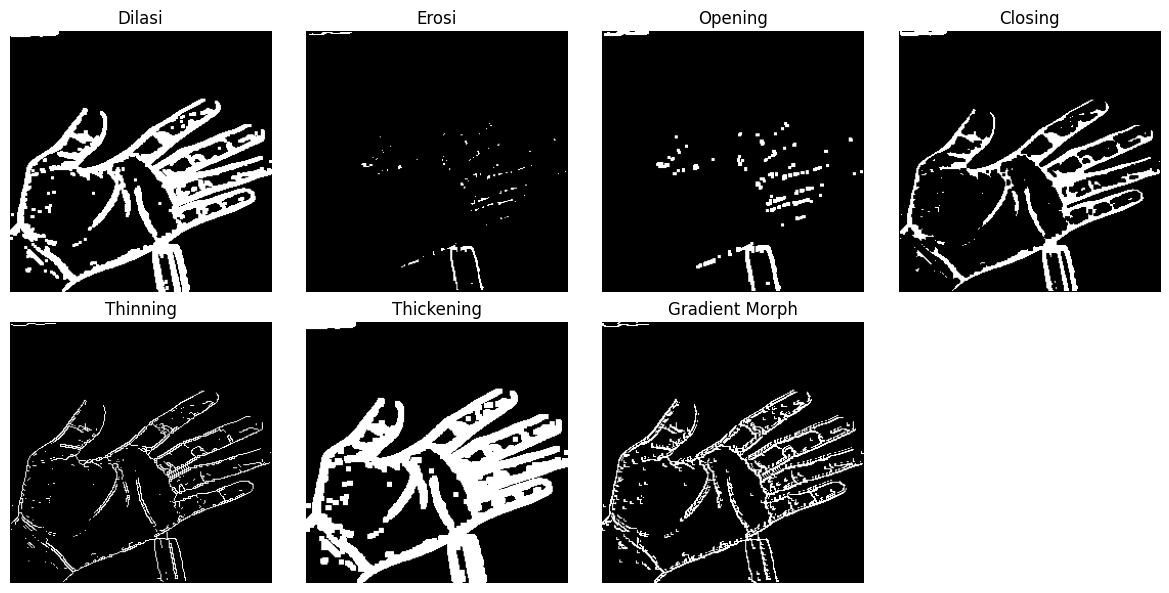

In [145]:
tangan_dilasi = metode_satu(threshold_10, np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]]))
tangan_erosi = metode_dua(threshold_10, np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]]))

tangan_opening = metode_satu(tangan_erosi, np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]]))
tangan_closing = metode_dua(tangan_dilasi, np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]]))

tangan_thinning = metode_tiga(threshold_10)
tangan_thickening = metode_empat(threshold_10, np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]]), iterasi=2)

gradient_morph = edge(tangan_thinning, prewittX, prewittY)

plt.figure(figsize=(12, 6))
plt.subplot(2, 4, 1)
plt.imshow(tangan_dilasi, cmap='gray')
plt.title('Dilasi')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(tangan_erosi, cmap='gray')
plt.title('Erosi')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(tangan_opening, cmap='gray')
plt.title('Opening')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(tangan_closing, cmap='gray')
plt.title('Closing')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(tangan_thinning, cmap='gray')
plt.title('Thinning')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(tangan_thickening, cmap='gray')
plt.title('Thickening')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(gradient_morph, cmap='gray')
plt.title('Gradient Morph')
plt.axis('off')

plt.tight_layout()
plt.show()